```
High Dynamic Range Imaging
```

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

```
Capture Multiple exposure
```

In [ ]:
def readImagesandTime():
  #list of image files
  files=["img_0.033.jpg","img_0.25.jpg","img_2.5.jpg","img_15.jpg"]
  # list of time
  time=np.array([1/30.0,0.25,2.5,15.0],dtype=np.float32)
  # read images
  image=[]
  for filename in files:
    im=cv.imread(filename,1)
    image.append(im)

  return image,time

```
Align Images
```

In [ ]:
#Read images and exposure time
image,time=readImagesandTime()
align=cv.createAlignMTB()
align.process(image,image)

```
Estimate camera response function
```

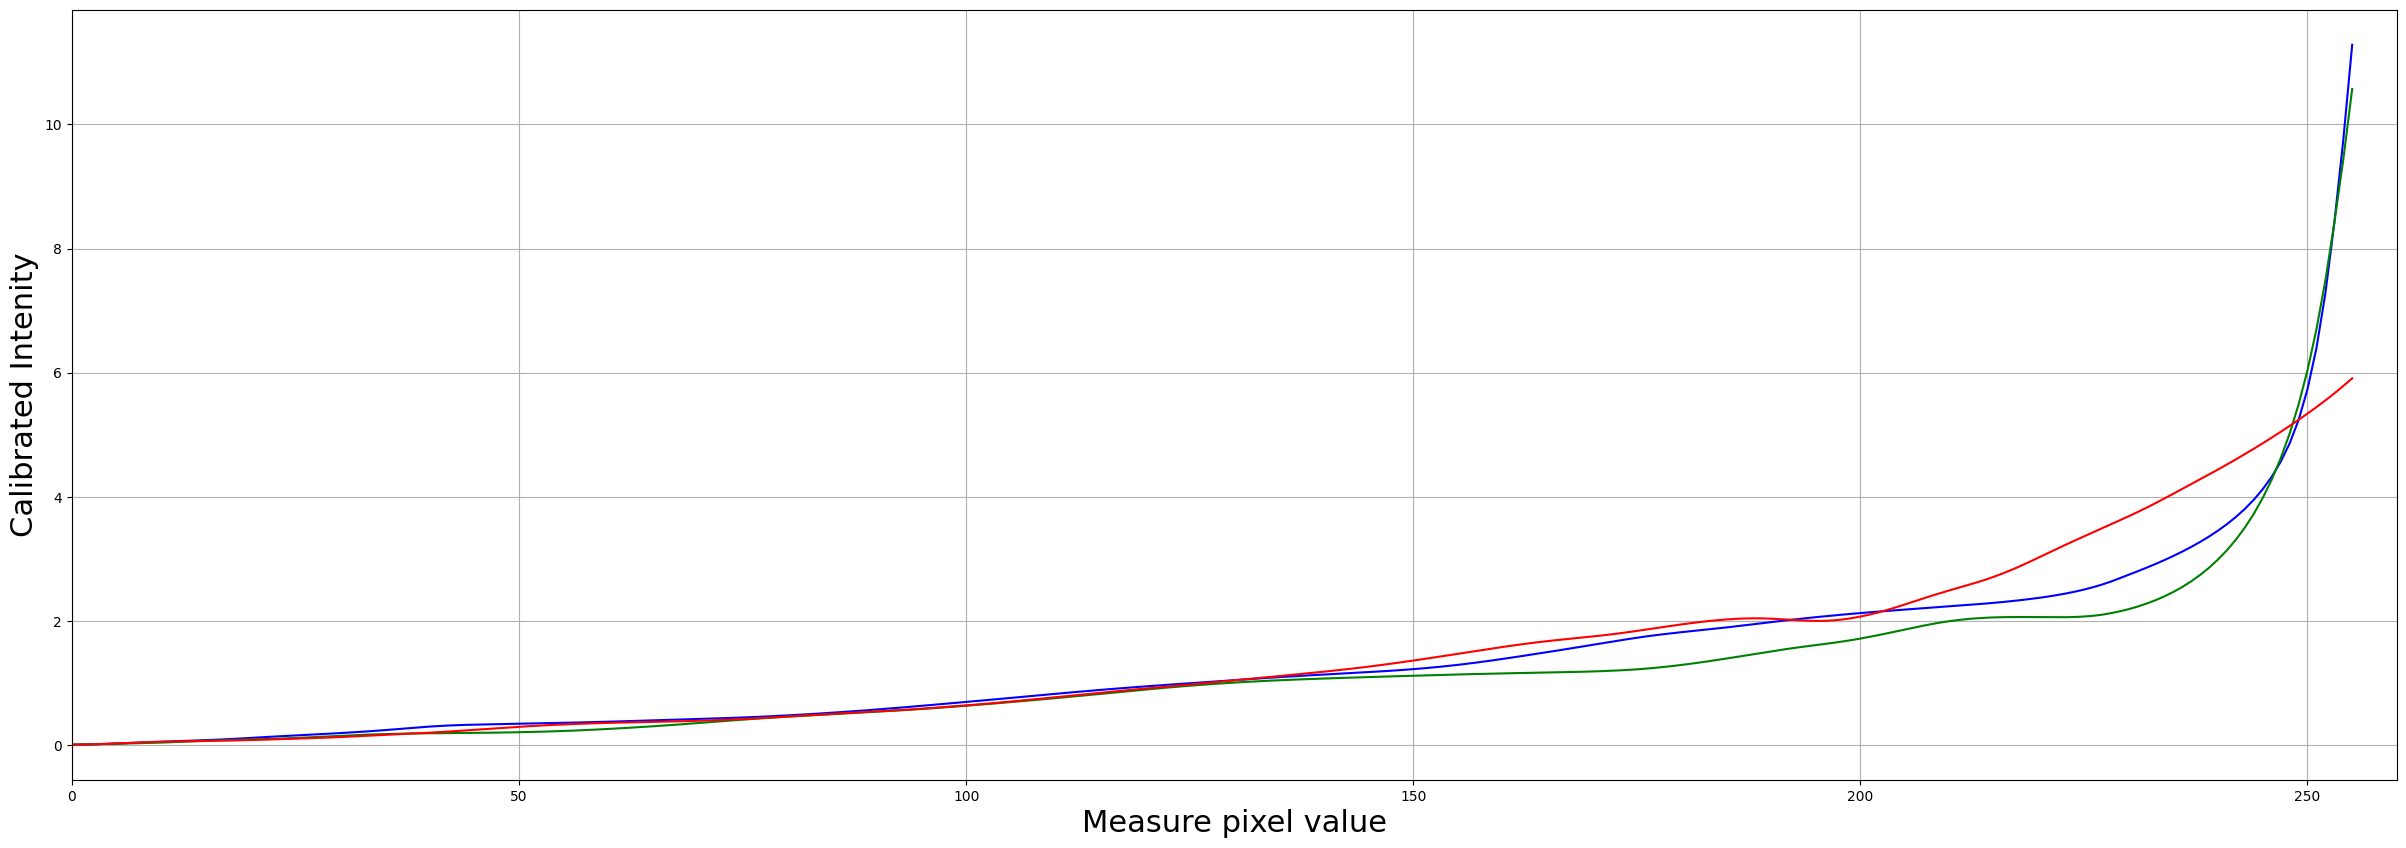

In [ ]:
#Camera Response Curve
curve=cv.createCalibrateDebevec()
reponseDebevec=curve.process(image,time)
x=np.arange(256,dtype=np.uint8) # creating an array of numbr  [0-255]-- representing all pixel  intensity values
#responseDebevec usually have a shape of (256,1,3) where 1 is a unneccessary dimension so we remov it using squeeze
y=np.squeeze(reponseDebevec)
#Plot CRF
plt.figure(figsize=(30,10))
plt.xlabel("Measure pixel value",fontsize=22)
plt.ylabel("Calibrated Intenity",fontsize=22)
plt.xlim([0,260])
plt.grid()
plt.plot(x,y[:,0],"b",x,y[:,1],"g",x,y[:,2],"r")

```
Merge Exposure in HDR images
```

In [ ]:
mergeExposure=cv.createMergeDebevec()
merge=mergeExposure.process(image,time,reponseDebevec)

```
There are more open cv algorithm we choose the most flexible  one Drago!!.It has more controls
```

(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

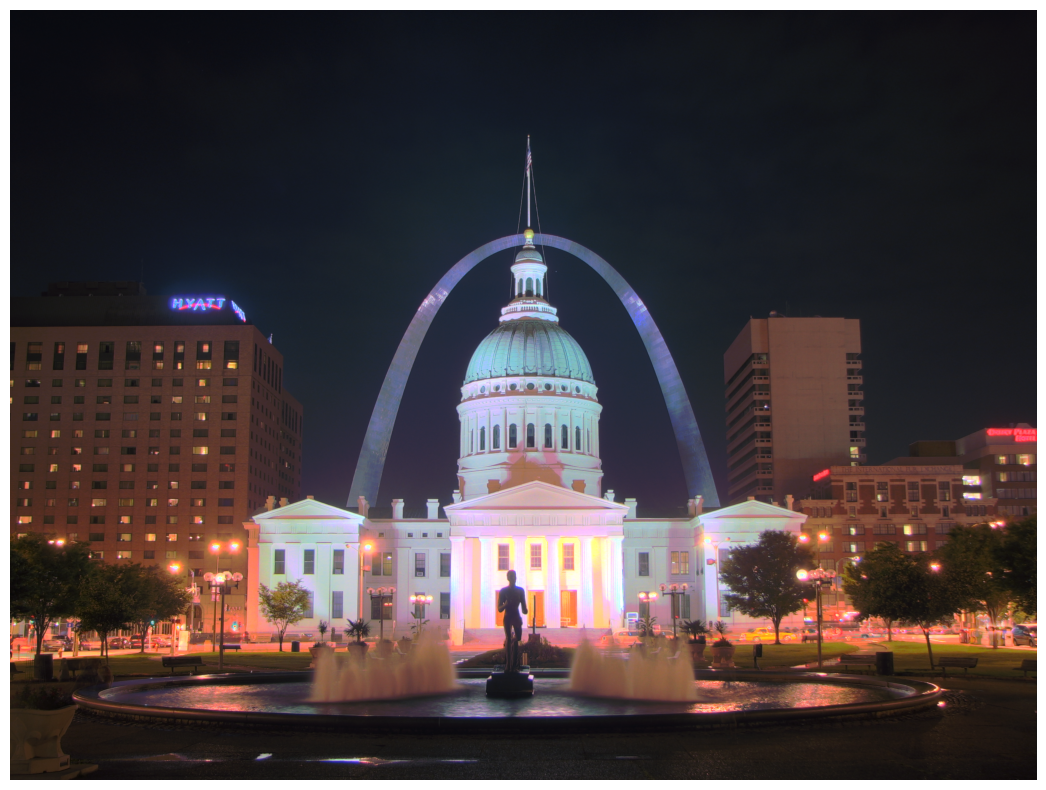

In [ ]:
# Tone mapping using Drago's method
tonemapdrago=cv.createTonemapDrago(1.0,0.7)
'''gamma-->control overall brightness correction
   saturation --> control vibrancy
'''
ldrDrago=tonemapdrago.process(merge)
ldrDrago=3*ldrDrago # Drago output is often dark multiplying it with 3 often brighten the image
#Saving image
cv.imwrite("ldr-drago.jpg",255*ldrDrago)
#Plotting image
plt.figure(figsize=(20,10));plt.imshow(np.clip(ldrDrago,0,1)[:,:,::-1]);plt.axis("off")

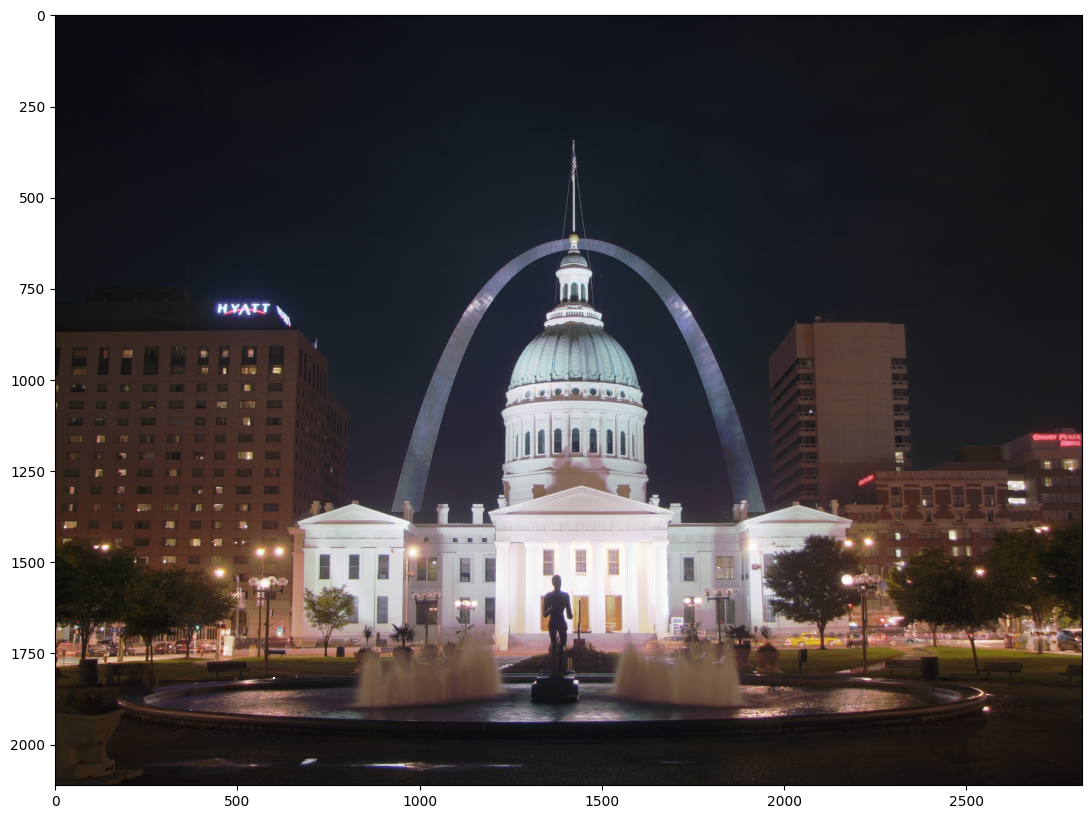

In [ ]:
# Tone mapping using reinhard's method
toneMapReinhard=cv.createTonemapReinhard(1.5,0,0,0)
'''
    gamma > 1 -- darker image gamma<1 -- brighter image gamma=1 -- neutral
    intensity -- control overall scene brightness range(-8 to +8)
    lightadapt -- control how much tone mapping adapt to local brightness
                  0 -- Global adaption (whole image treated uniformly)
                  1 -- Local adaptive (each region adjuted seperately)
    color-adapt -- controls color preservation during tone mapping
                  0 -- preserves original color
                  1-- allows color adaption


'''
ldrReinhard=toneMapReinhard.process(merge)
#Saving the image
cv.imwrite("ldr-reinhard.jpg",ldrReinhard*255)
#Plot  the image
plt.figure(figsize=(20,10));plt.imshow(np.clip(ldrReinhard,0,1)[:,:,::-1])


(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

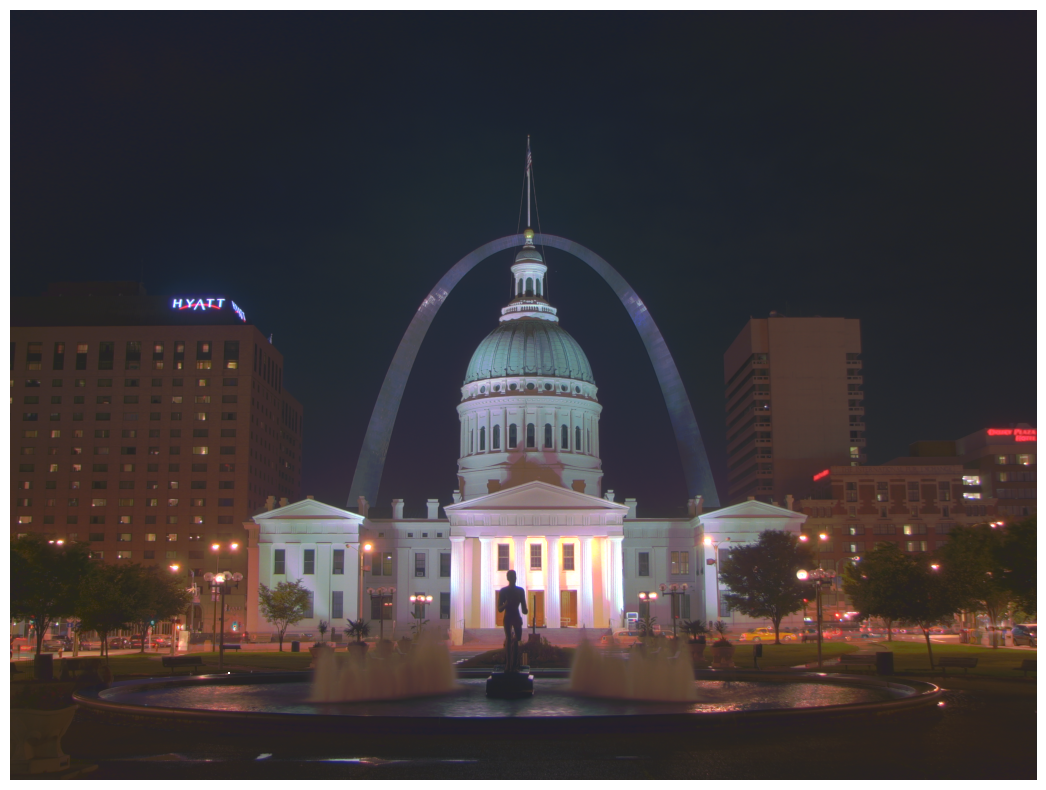

In [ ]:
# Tone mapping uing mantiuk's algorithm
toneMantiuk=cv.createTonemapMantiuk(2.2,0.85,1.2)
'''
gamma range 1.0-2.5 higher gamma darker image lower gamma brighter image
scale-0.85 It controls how strongly contrast is enhanced higher value stong contrast range 0.6-1.0
saturation-1.2 color intensity. Control how vividly the color appears 1.0 -- natural colour > 1.0 more vivid colours < 1.0 -- muted colors
'''
ldrMantiuk=toneMantiuk.process(merge)
ldrMantiuk=3*ldrMantiuk
#Saving the image
cv.imwrite("ldr-mantiuk.jpg",ldrMantiuk*255)
#Plot the image
plt.figure(figsize=(20,10));plt.imshow(np.clip(ldrMantiuk,0,1)[:,:,::-1]);plt.axis("off")
